# Performance eval, results, and plotting

All experiments ran with fixed beta=2.0, tested at different degrees of misspecification and sample sizes

1. Ricker NPE
2. Ricker ABC
3. Plotting

In [95]:
import sys
sys.path.append('../')
import utils.metrics as metrics
import numpy as np
import torch
import io
import pickle
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import norm, qmc
from scipy import stats as stats
from simulators.oup import oup
from simulators.ricker import ricker
from simulators.turin import turin
from utils.metrics import RMSE

import warnings
warnings.filterwarnings('ignore')
        
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [96]:
# Utility functions

class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else: return super().find_class(module, name)

def load_npe_models(root_name: str, device: torch.device):
    sum_net = torch.load("{root_name}/sum_net.pkl".format(root_name=root_name), map_location=device)

    density_estimator = torch.load("{root_name}/density_estimator.pkl".format(root_name=root_name), map_location=device)

    with open("{root_name}/posterior.pkl".format(root_name=root_name), "rb") as handle:
        posterior = CPU_Unpickler(handle).load() if device == torch.device('cpu') else pickle.load(handle)
    
    return sum_net, density_estimator, posterior


def read_rnpe(model="oup", var=1.0, degree=0, seed=1, theta=[0.5,1.0]):
    file = f"seed={seed}_degree={degree if float(degree)!=0 else 0}_var={var}_theta={theta}_{model}"

    results_dir = f"../objects/RNPE/{model}_final"
    fn = f"{results_dir}/{file}.pickle"

    with open(fn, "rb") as f:
        results = pickle.load(f)

    return np.array(results['posterior_samples']['RNPE'])


def sample_posteriors(posterior, obs, num, n_realizations):
    return posterior.sample((num,), x=obs.reshape(1, 1, n_realizations, -1), show_progress_bars=False)


def temporalMomentsGeneral(Y, K=3, B=4e9):
    N, Ns = Y.shape
    tau = np.linspace(0, 100, Ns)
    out = np.zeros((N, K))
    Y = Y.detach().numpy()
    for k in range(K):
        for i in range(N):
            out[i, k] = np.trapz(tau**(k) * Y[i], tau) + 1e-4
    return np.log(out)


def generate_u(N, timesteps, engine=None):
    """
    Generates a (N, T) block of noise.
    If engine is provided, it draws the next sequence in the Sobol chain.
    """
    if engine is not None:
        u_uniform = engine.random(N)
        # Map [0, 1] to [0.0001, 0.9999]
        # This keeps Gaussian noise within approx +/- 3.7 standard deviations
        u_safe = 1e-4 + (u_uniform * (1 - 2e-4))
        return torch.tensor(stats.norm.ppf(u_safe), dtype=torch.float32, device=device)
    else:
        return torch.randn(N, timesteps).to(device)

## Shared parameters

In [97]:
beta = 2.0
degrees = [0, 0.1, 0.2]
sample_sizes = [256, 128, 32]
n_realizations = 128
n_reruns = 5
t_ricker = 100

theta_gt = torch.tensor([4, 10])
theta_gt_str = "[4, 10]"

# Define ricker simulator
sim_N = 1

qmc_engine = qmc.Sobol(d=t_ricker, scramble=True)

u = generate_u(sim_N, t_ricker)
u_qmc = generate_u(sim_N, t_ricker, qmc_engine)

simulator = ricker(u, sim_N)
simulator_qmc = ricker(u_qmc, sim_N)

n_samples_rmse = 1024
n_samples_mmd = 1024

load_ricker_obs = lambda degree : torch.tensor(np.load(f"../data/ricker_obs_{int(degree * 10)}.npy")).to(device=device)

## 1. Ricker NPE

In [98]:
n_samples_npe = 1024

### 1.1 RMSE on NPE

In [99]:
ricker_rmse_npe_rs = np.zeros((len(sample_sizes), len(degrees)))
ricker_rmse_npe_eff = np.zeros((len(sample_sizes), len(degrees)))

# iterate through parameters

for s, sample_size in enumerate(sample_sizes):
    for d, degree in enumerate(degrees):
        rmse_npe_rs = np.zeros(n_reruns)
        rmse_npe_eff = np.zeros(n_reruns)

        obs = load_ricker_obs(degree)

        for i in range(n_reruns):
            robust_root = f"../objects/NPE/ricker/degree={degree:.1f}_mmd_beta={beta}_theta={theta_gt_str}_num={n_samples_npe}_size={sample_size}/{i}"
            _, _, posterior_robust_npe = load_npe_models(root_name=robust_root, device=device)
            posterior_robust_samps = sample_posteriors(posterior_robust_npe, obs, n_samples_rmse, n_realizations)

            efficient_root = f"../objects/NPE/ricker/degree={degree:.1f}_mmd-efficient_beta={beta}_theta={theta_gt_str}_num={n_samples_npe}_size={sample_size}/{i}"
            _, _, posterior_efficient_npe = load_npe_models(root_name=efficient_root, device=device)
            posterior_efficient_samps = sample_posteriors(posterior_efficient_npe, obs, n_samples_rmse, n_realizations)

            rmse_npe_rs[i] = float(RMSE(theta_gt, posterior_robust_samps, p=2))
            rmse_npe_eff[i] = float(RMSE(theta_gt, posterior_efficient_samps, p=2))

        ricker_rmse_npe_rs[d, s] = np.mean(rmse_npe_rs)
        ricker_rmse_npe_eff[d, s] = np.mean(rmse_npe_eff)
        
        print(f"-- RMSE at degree of misspecification {degree} with sample size {sample_size} --")
        print(f"NPE-RS: {ricker_rmse_npe_rs[d, s]}")
        print(f"NPE-EFF: {ricker_rmse_npe_eff[d, s]}")
            

-- RMSE at degree of misspecification 0 with sample size 256 --
NPE-RS: 3.484054183959961
NPE-EFF: 2.8614945650100707
-- RMSE at degree of misspecification 0.1 with sample size 256 --
NPE-RS: 4.745817422866821
NPE-EFF: 4.410016393661499
-- RMSE at degree of misspecification 0.2 with sample size 256 --
NPE-RS: 6.886533260345459
NPE-EFF: 10.086403799057006
-- RMSE at degree of misspecification 0 with sample size 128 --
NPE-RS: 3.3327356815338134
NPE-EFF: 3.2309829950332642
-- RMSE at degree of misspecification 0.1 with sample size 128 --
NPE-RS: 6.1077765941619875
NPE-EFF: 5.431429100036621
-- RMSE at degree of misspecification 0.2 with sample size 128 --
NPE-RS: 4.479360914230346
NPE-EFF: 6.868194150924682
-- RMSE at degree of misspecification 0 with sample size 32 --
NPE-RS: 3.189437007904053
NPE-EFF: 3.2604251384735106
-- RMSE at degree of misspecification 0.1 with sample size 32 --
NPE-RS: 5.859192657470703
NPE-EFF: 4.962978553771973
-- RMSE at degree of misspecification 0.2 with sam

### 1.2 MMD on NPE

In [ ]:
ricker_mmd_npe_rs = np.zeros((len(sample_sizes), len(degrees)))
ricker_mmd_npe_eff = np.zeros((len(sample_sizes), len(degrees)))

for s, sample_size in enumerate(sample_sizes):
    for d, degree in enumerate(degrees):
        obs = load_ricker_obs(degree)
        obs_stats = torch.tensor(temporalMomentsGeneral(obs.reshape(n_realizations, t_ricker)))

        mmd_npe_rs = np.zeros(n_reruns)
        mmd_npe_eff = np.zeros(n_reruns)

        for i in range(n_reruns):
            # robust method
            robust_root = f"../objects/NPE/ricker/degree={degree:.1f}_mmd_beta={beta}_theta={theta_gt_str}_num={n_samples_npe}_size={sample_size}/{i}"
            _, _, posterior_robust_npe = load_npe_models(root_name=robust_root, device=device)
            posterior_robust_samps = sample_posteriors(posterior_robust_npe, obs, n_samples_mmd, n_realizations)

            predictive_data_npe_rs = torch.zeros(n_samples_mmd, t_ricker)
            for j in range(n_samples_mmd):
                predictive_data_npe_rs[j] = simulator(posterior_robust_samps[j])[0]

            pred_stat_npe_rs = torch.tensor(temporalMomentsGeneral(predictive_data_npe_rs))
            mmd_npe_rs[i] = float(metrics.MMD_unweighted(pred_stat_npe_rs, obs_stats, lengthscale=1))

            # our method
            efficient_root = f"../objects/NPE/ricker/degree={degree:.1f}_mmd-efficient_beta={beta}_theta={theta_gt_str}_num={n_samples_npe}_size={sample_size}/{i}"
            _, _, posterior_efficient_npe = load_npe_models(root_name=efficient_root, device=device)
            posterior_efficient_samps = sample_posteriors(posterior_efficient_npe, obs, n_samples_mmd, n_realizations)

            predictive_data_npe_eff = torch.zeros(n_samples_mmd, t_ricker)
            for j in range(n_samples_mmd):
                predictive_data_npe_eff[j] = simulator_qmc(posterior_efficient_samps[j])[0]

            pred_stat_npe_eff = torch.tensor(temporalMomentsGeneral(predictive_data_npe_eff))
            mmd_npe_eff[i] = float(metrics.MMD_unweighted(pred_stat_npe_eff, obs_stats, lengthscale=1))
        
        ricker_mmd_npe_rs[d, s] = np.mean(mmd_npe_rs[~np.isnan(mmd_npe_rs)])
        ricker_mmd_npe_eff[d, s] = np.mean(mmd_npe_eff[~np.isnan(mmd_npe_eff)])
        
        print(f"-- MMD at degree of misspecification {degree} with sample size {sample_size} --")
        print(f"NPE-RS: {ricker_mmd_npe_rs[d, s]}")
        print(f"NPE-EFF: {ricker_mmd_npe_eff[d, s]}")


-- MMD at degree of misspecification 0 with sample size 256 --
NPE-RS: 0.29411469566012727
NPE-EFF: 0.2673560575794197
-- MMD at degree of misspecification 0.1 with sample size 256 --
NPE-RS: 0.34488595959506774
NPE-EFF: 0.23107212311451164
-- MMD at degree of misspecification 0.2 with sample size 256 --
NPE-RS: 0.3350257193906749
NPE-EFF: 0.5574115980984494
-- MMD at degree of misspecification 0 with sample size 128 --
NPE-RS: 0.23147451539235
NPE-EFF: 0.30257175342100984
-- MMD at degree of misspecification 0.1 with sample size 128 --
NPE-RS: 0.3574762200598672
NPE-EFF: 0.24128712764609705
-- MMD at degree of misspecification 0.2 with sample size 128 --
NPE-RS: 0.17763702389517771
NPE-EFF: 0.32415479015843374
-- MMD at degree of misspecification 0 with sample size 32 --
NPE-RS: 0.2751499911779042
NPE-EFF: 0.2989831230022867
-- MMD at degree of misspecification 0.1 with sample size 32 --
NPE-RS: 0.30516301057046674
NPE-EFF: 0.3569905616993768
-- MMD at degree of misspecification 0.2 w

## 2. Ricker ABC

In [101]:
n_samples_abc = 4096
n_reruns_abc = 10

### 2.1 RMSE on ABC

In [102]:
ricker_rmse_abc = np.zeros((len(sample_sizes), len(degrees)))
ricker_rmse_abc_rs = np.zeros((len(sample_sizes), len(degrees)))
ricker_rmse_abc_eff = np.zeros((len(sample_sizes), len(degrees)))

# iterate through parameters

for s, sample_size in enumerate(sample_sizes):
    for d, degree in enumerate(degrees):
        rmse_abc = np.zeros(n_reruns_abc)
        rmse_abc_rs = np.zeros(n_reruns_abc)
        rmse_abc_eff = np.zeros(n_reruns_abc)

        obs = load_ricker_obs(degree)

        for i in range(n_reruns_abc):
            normal_root = f"../objects/ABC/ricker_4096/degree={degree}/lambda={int(beta)}/sample_size={sample_size}/{i}/posterior_normal.npy"
            posterior_normal_samps = np.load(normal_root)

            robust_root = f"../objects/ABC/ricker_4096/degree={degree}/lambda={int(beta)}/sample_size={sample_size}/{i}/posterior_robust.npy"
            posterior_robust_samps = np.load(robust_root)

            efficient_root = f"../objects/ABC/ricker_4096/degree={degree}/lambda={int(beta)}/sample_size={sample_size}/{i}/posterior_efficient.npy"
            posterior_efficient_samps = np.load(efficient_root)

            rmse_abc[i] = float(RMSE(theta_gt, posterior_normal_samps, p=2))
            rmse_abc_rs[i] = float(RMSE(theta_gt, posterior_robust_samps, p=2))
            rmse_abc_eff[i] = float(RMSE(theta_gt, posterior_efficient_samps, p=2))

        ricker_rmse_abc[d, s] = np.mean(rmse_abc)
        ricker_rmse_abc_rs[d, s] = np.mean(rmse_abc_rs)
        ricker_rmse_abc_eff[d, s] = np.mean(rmse_abc_eff)
        
        print(f"-- RMSE at degree of misspecification {degree} with sample size {sample_size} --")
        print(f"NPE    : {ricker_rmse_abc[d, s]}")
        print(f"NPE-RS : {ricker_rmse_npe_rs[d, s]}")
        print(f"NPE-EFF: {ricker_rmse_npe_eff[d, s]}")
            

-- RMSE at degree of misspecification 0 with sample size 256 --
NPE    : 1.5379308962626275
NPE-RS : 3.484054183959961
NPE-EFF: 2.8614945650100707
-- RMSE at degree of misspecification 0.1 with sample size 256 --
NPE    : 5.820613807757292
NPE-RS : 4.745817422866821
NPE-EFF: 4.410016393661499
-- RMSE at degree of misspecification 0.2 with sample size 256 --
NPE    : 9.618339658752827
NPE-RS : 6.886533260345459
NPE-EFF: 10.086403799057006
-- RMSE at degree of misspecification 0 with sample size 128 --
NPE    : 1.2797242242344264
NPE-RS : 3.3327356815338134
NPE-EFF: 3.2309829950332642
-- RMSE at degree of misspecification 0.1 with sample size 128 --
NPE    : 5.681669267487038
NPE-RS : 6.1077765941619875
NPE-EFF: 5.431429100036621
-- RMSE at degree of misspecification 0.2 with sample size 128 --
NPE    : 9.458578525665665
NPE-RS : 4.479360914230346
NPE-EFF: 6.868194150924682
-- RMSE at degree of misspecification 0 with sample size 32 --
NPE    : 1.2390471437674344
NPE-RS : 3.1894370079040

### 2.2 MMD on ABC

In [103]:
ricker_mmd_abc = np.zeros((len(sample_sizes), len(degrees)))
ricker_mmd_abc_rs = np.zeros((len(sample_sizes), len(degrees)))
ricker_mmd_abc_eff = np.zeros((len(sample_sizes), len(degrees)))

for s, sample_size in enumerate(sample_sizes):
    for d, degree in enumerate(degrees):
        obs = load_ricker_obs(degree)
        obs_stats = torch.tensor(temporalMomentsGeneral(obs.reshape(n_realizations, t_ricker)))

        mmd_abc = np.zeros(n_reruns_abc)
        mmd_abc_rs = np.zeros(n_reruns_abc)
        mmd_abc_eff = np.zeros(n_reruns_abc)

        for i in range(n_reruns_abc):
            # normal method
            normal_root = f"../objects/ABC/ricker_4096/degree={degree}/lambda={int(beta)}/sample_size={sample_size}/{i}/posterior_normal.npy"
            posterior_normal = np.load(normal_root)
            posterior_normal_samps = torch.tensor(posterior_normal[np.random.choice(posterior_normal.shape[0], n_samples_mmd)])

            predictive_data_abc = torch.zeros(n_samples_mmd, t_ricker)
            for j in range(n_samples_mmd):
                predictive_data_abc[j] = simulator(posterior_normal_samps[j])[0]

            pred_stat_abc = torch.tensor(temporalMomentsGeneral(predictive_data_abc))
            mmd_abc[i] = float(metrics.MMD_unweighted(pred_stat_abc, obs_stats, lengthscale=1))

            # robust method
            robust_root = f"../objects/ABC/ricker_4096/degree={degree}/lambda={int(beta)}/sample_size={sample_size}/{i}/posterior_robust.npy"
            posterior_robust = np.load(robust_root)
            posterior_robust_samps = torch.tensor(posterior_robust[np.random.choice(posterior_robust.shape[0], n_samples_mmd)])

            predictive_data_abc_rs = torch.zeros(n_samples_mmd, t_ricker)
            for j in range(n_samples_mmd):
                predictive_data_abc_rs[j] = simulator(posterior_robust_samps[j])[0]

            pred_stat_abc_rs = torch.tensor(temporalMomentsGeneral(predictive_data_abc_rs))
            mmd_abc_rs[i] = float(metrics.MMD_unweighted(pred_stat_abc_rs, obs_stats, lengthscale=1))

            # our method
            efficient_root = f"../objects/ABC/ricker_4096/degree={degree}/lambda={int(beta)}/sample_size={sample_size}/{i}/posterior_efficient.npy"
            posterior_efficient = np.load(efficient_root)
            posterior_efficient_samps = torch.tensor(posterior_efficient[np.random.choice(posterior_efficient.shape[0], n_samples_mmd)])

            predictive_data_abc_eff = torch.zeros(n_samples_mmd, t_ricker)
            for j in range(n_samples_mmd):
                predictive_data_abc_eff[j] = simulator_qmc(posterior_efficient_samps[j])[0]

            pred_stat_abc_eff = torch.tensor(temporalMomentsGeneral(predictive_data_abc_eff))
            mmd_abc_eff[i] = float(metrics.MMD_unweighted(pred_stat_abc_eff, obs_stats, lengthscale=1))
        
        ricker_mmd_abc[d, s] = np.mean(mmd_abc[~np.isnan(mmd_abc)])
        ricker_mmd_abc_rs[d, s] = np.mean(mmd_abc_rs[~np.isnan(mmd_abc_rs)])
        ricker_mmd_abc_eff[d, s] = np.mean(mmd_abc_eff[~np.isnan(mmd_abc_eff)])
        
        print(f"-- MMD at degree of misspecification {degree} with sample size {sample_size} --")
        print(f"ABC: {ricker_mmd_abc[d, s]}")
        print(f"ABC-RS: {ricker_mmd_abc_rs[d, s]}")
        print(f"ABC-EFF: {ricker_mmd_abc_eff[d, s]}")


-- MMD at degree of misspecification 0 with sample size 256 --
ABC: 0.0028908362353364248
ABC-RS: 0.08444649322764801
ABC-EFF: 0.07084950109420175
-- MMD at degree of misspecification 0.1 with sample size 256 --
ABC: 0.7657183491772593
ABC-RS: 0.1508954285888321
ABC-EFF: 0.24784557223525408
-- MMD at degree of misspecification 0.2 with sample size 256 --
ABC: 1.1651946904151758
ABC-RS: 0.28342694880559444
ABC-EFF: 0.3413215900929786
-- MMD at degree of misspecification 0 with sample size 128 --
ABC: 0.0033574980044653755
ABC-RS: 0.03071384611505503
ABC-EFF: 0.014219245442648265
-- MMD at degree of misspecification 0.1 with sample size 128 --
ABC: 0.7564148889297695
ABC-RS: 0.447600269287301
ABC-EFF: 0.30570728139080666
-- MMD at degree of misspecification 0.2 with sample size 128 --
ABC: 1.1734612235365804
ABC-RS: 0.26720748837730024
ABC-EFF: 0.3670736589225059
-- MMD at degree of misspecification 0 with sample size 32 --
ABC: 0.0017959797004883705
ABC-RS: 0.040308905588868446
ABC-EFF:

## 3. Plotting

### 3.1 Define general function for plotting posterior joint distributions

In [104]:
def plot_posterior_joints(*, normal=None, robust=None, efficient=None, method_label="NPE", height=5):
      theta_gt = [4, 10]

      graph = sns.jointplot(x=robust[:, 0], y=robust[:, 1],
            cmap="Blues", kind="kde", height=height, marginal_kws={"color":"C0", "alpha":.5, "shade":True}, shade=True, thresh=0.05, alpha=.5,
            label="Robust") 

      # plot joint with robust
      from matplotlib.patches import Patch
      from matplotlib.lines import Line2D

      legend_elements = [Line2D([0], [0], color='k', lw=1, label='True $\\theta$')]

      if (normal is not None):
            graph.x = normal[:, 0]
            graph.y = normal[:, 1]
            graph.plot_joint(sns.kdeplot, cmap="Oranges", shade=True, alpha=.5, label='Robust')
            graph.ax_joint.axvline(x=theta_gt[0], lw=1, ls="-",c="black", label="True $\\theta$")
            graph.ax_joint.axhline(y=theta_gt[1], lw=1, ls="-",c="black")
            graph.plot_marginals(sns.kdeplot, color='C1', shade=True, alpha=.5, legend=False)

            legend_elements.append(Patch(facecolor='C1', edgecolor='C1', label=method_label))

      # plot joint with robust-efficient

      graph.x = efficient[:, 0]
      graph.y = efficient[:, 1]
      graph.plot_joint(sns.kdeplot, cmap="Greens", shade=True, alpha=.5, label='Ours')
      graph.ax_joint.axvline(x=theta_gt[0], lw=1, ls="-",c="black", label="True $\\theta$")
      graph.ax_joint.axhline(y=theta_gt[1], lw=1, ls="-",c="black")
      graph.plot_marginals(sns.kdeplot, color='C2', shade=True, alpha=.5, legend=False)

      graph.ax_joint.axvline(x=2, ls="--", lw=1, c="gray", alpha=0.3)
      graph.ax_joint.axvline(x=8, ls="--", lw=1, c="gray", alpha=0.3)

      graph.ax_joint.axhline(y=0, ls="--", lw=1,c="gray", alpha=0.3)
      graph.ax_joint.axhline(y=20, ls="--", lw=1, c="gray", alpha=0.3)

      legend_elements.append(Patch(facecolor='C0', edgecolor='C0', label='Robust'))
      legend_elements.append(Patch(facecolor='C2', edgecolor='C2', label='Ours'))

      graph.ax_joint.legend(handles=legend_elements, loc='upper right', fontsize=13) 

      graph.ax_joint.set_xlabel('$\\theta_1$')
      graph.ax_joint.set_ylabel('$\\theta_2$')

      plt.tight_layout()
      plt.show()

### 3.2 Define some helper functions for loading posteriors

In [105]:
def load_abc_posteriors(degree=0, sample_size=128, sample=0):
    posterior_normal = np.load(f"../objects/ABC/ricker_4096/degree={degree}/lambda={int(beta)}/sample_size={sample_size}/{sample}/posterior_normal.npy")
    posterior_robust = np.load(f"../objects/ABC/ricker_4096/degree={degree}/lambda={int(beta)}/sample_size={sample_size}/{sample}/posterior_robust.npy")
    posterior_robust_efficient = np.load(f"../objects/ABC/ricker_4096/degree={degree}/lambda={int(beta)}/sample_size={sample_size}/{sample}/posterior_efficient.npy")

    return posterior_normal, posterior_robust, posterior_robust_efficient

In [106]:
def load_npe_posteriors(degree, sample_size, sample):
    obs = load_ricker_obs(degree)
    robust_root = f"../objects/NPE/ricker/degree={degree:.1f}_mmd_beta={beta}_theta={theta_gt_str}_num={n_samples_npe}_size={sample_size}/{sample}"
    _, _, posterior_robust_npe = load_npe_models(root_name=robust_root, device=device)
    posterior_robust_samps = sample_posteriors(posterior_robust_npe, obs, n_samples_npe, n_realizations)

    efficient_root = f"../objects/NPE/ricker/degree={degree:.1f}_mmd-efficient_beta={beta}_theta={theta_gt_str}_num={n_samples_npe}_size={sample_size}/{sample}"
    _, _, posterior_efficient_npe = load_npe_models(root_name=efficient_root, device=device)
    posterior_efficient_samps = sample_posteriors(posterior_efficient_npe, obs, n_samples_npe, n_realizations)

    return posterior_robust_samps, posterior_efficient_samps

### 3.3 Plot ABC

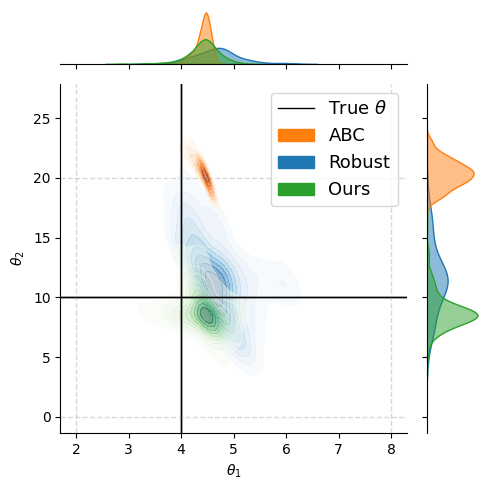

In [107]:
target_degree = 0.2
ss = 128
i = 3

abc, abc_rs, abc_eff = load_abc_posteriors(target_degree, sample_size, i)

plot_posterior_joints(normal=abc, robust=abc_rs, efficient=abc_eff, method_label="ABC")

### 3.4 Plot NPE

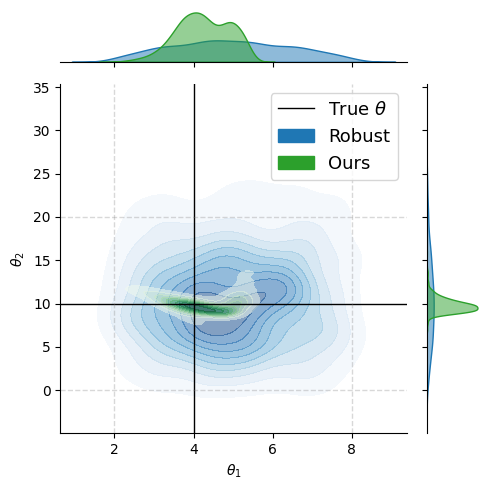

In [108]:
target_degree = 0
ss = 256
i = 0

post_npe_rs, post_npe_eff = load_npe_posteriors(target_degree, sample_size, i)

plot_posterior_joints(robust=post_npe_rs, efficient=post_npe_eff)